In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.ion()

In [6]:
K=10
## structure de données:
# p_kd: dimensions (K, D) matrice de la proba p(k,d) que le pixel d soit allumé pour les images de classe k
# P_k : dimension  (K)    matrice des probas de classe: P(y_true == k) est la proba qu'une image prise au hasard soit de classe k.


## Version de MNIST (très) réduite

In [7]:
######### les données ################
import sklearn.datasets
X,y = sklearn.datasets.load_digits(n_class=K, return_X_y=True)
Dlin=8

## Version de MNIST plus grande : 

Dans un terminal:
`wget https://gitlab.inria.fr/flandes/data-for-teaching/-/raw/master/mnist70.npz`

In [8]:
# Tapez dans un terminal (dans le meme dossier que le dossier courant ou se trouve ce notebook):
# wget https://gitlab.inria.fr/flandes/data-for-teaching/-/raw/master/mnist70.npz
# 
data = np.load('./mnist70.npz', 'X', 'y')
X = data['X']
y = data['y']
print(X.shape)
Dlin=28

FileNotFoundError: [Errno 2] No such file or directory: './mnist70.npz'

Text(0.5, 1.0, 'ceci est censé ressembler à un 0 avant la binarisation')

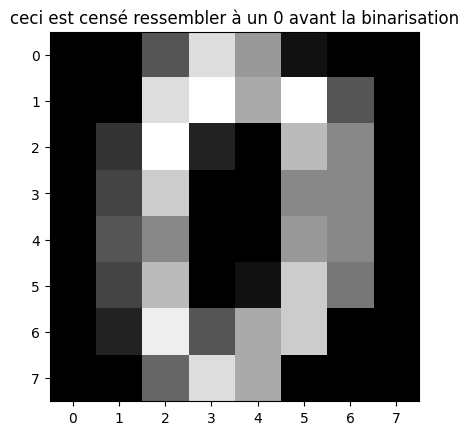

In [ ]:
######################################
## petite demo d'affichage ##
plt.figure()
n=0 # image numero n
plt.imshow(X[n].reshape(Dlin,Dlin) , cm.gray)
plt.title("ceci est censé ressembler à un "+str(y[n])+ " avant la binarisation")
# plt.show() ## inutile si on a mis plt.in() au début #
#############################

In [ ]:
##################################################
#### preparation des donnees (pre processing) ####

# on met X (les intensités de niveaux de gris) entre 0 et 1
X /= X.max()

In [ ]:
## on binarise X, de sorte que il vaut soit 0 soit 1,
## comme les valeurs prises par une loi de Bernoulli

## pour gagner du temps, le code vous est donné:
seuil = 0.5
X[X>=seuil] = 1
X[X<seuil] = 0

## dans le cas Gaussien, il n'est pas nécéssaire de binariser.


In [ ]:
X.shape, X.shape[0] 

((1797, 64), 1797)

In [ ]:
print("5 divisé par 2:\n=", 5//2 , "\nou bien:\n=", int(5/2)) ## division entière

5 divisé par 2:
= 2 
ou bien:
= 2


In [ ]:
## separation train/test (ici, il n'y a pas d'hyperparametres, pratiquement, donc on ne fait pas de validation)
## quoique... il y en a au moins un, lequel ?

## pour gagner du temps, le code vous est donné:
Ntot   = X.shape[0]      #Ntotal
Ntrain = int(Ntot*0.8)
Ntest  = Ntot-Ntrain

X_train = X[0: Ntrain]
X_test  = X[Ntrain:Ntot] # X[-Ntest:] est equivalent
y_train = y[0:Ntrain]
y_test  = y[Ntrain:Ntot]

print("X.shape", X.shape)

X.shape (1797, 64)


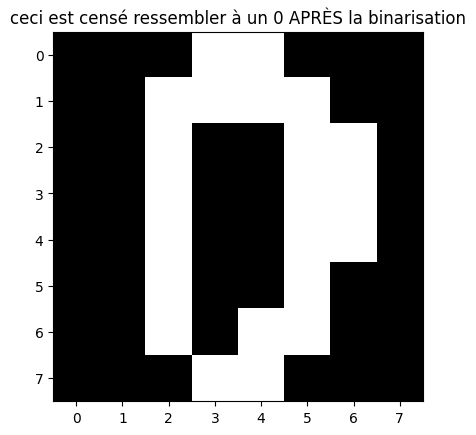

In [ ]:
#############################
## petite demo d'affichage ##
plt.figure()
n=0 # image numero 42
plt.imshow(X_train[n].reshape(Dlin,Dlin) , cm.gray)
plt.title("ceci est censé ressembler à un "+str(y_train[n])+" APRÈS la binarisation")
plt.show()
#############################

## TODO: écire le code:
- de la fonction d'entrainement (fit), `BayesienNaif_fit`
- de la focntion de prédiction, `BayesienNaif_predict`

In [ ]:
## l'algo d'apprentissage ##
def BayesienNaif_fit(X,y):
    N = X.shape[0]
    D = X.shape[1]
    p_kd = np.zeros((10,D))  # Tableau de taille 10xD qui va nous servir pour chaque classe k et pixel idx, 
    # à compter la proportion d'images de classe k tel que le pixel à la position idx vaille 1, cela dans le but d'obtenir P(X|Y)
    p_k = np.zeros(10) # Tableau de taille 10 qui va nous servir à compter le nombre d'image de classe k, dans le but d'obtenir  P(Y)

    for idx, image in enumerate(X): # image = X[idx] -> lire la doc de la fonction enumerate en Python
        k = y[idx]  # La classe de l'image d'index idx, est de classe y[idx], on sauvegarde donc cette classe (entre 0 et 9) dans k
        p_k[k] +=1  # On compte le nombre d'image de classe k
        for idx2, pixel in enumerate(image):
            p_kd[k][idx2] += pixel # Pour la classe k, le pixel à la position idx2, on ajoute la valeur du pixel 
            # (servant à compter ensuite la proportion valant 1)

    for k in range(10):
        p_kd[k] /= p_k[k] # En divisant par le nombre total d'images de classe k, on passe du nombre de pixel valant 1 pour chaque classe k 
        # à une proportion (probabilité) entre 0 et 1 

    p_k /= N  # En divisant par le nombre total d'images, on passe du nombre de d'image de classe k à une proportion (probabilité) entre 0 et 1 
    
    # Note : au lieu de toutes ces lignes il est possible de simplement d'écrire :
    # for k in range (10):
    #    p_kd[k] = np.mean(X_train [ y_train == k ] , axis =0)
    #    P_k[k] = np.mean(y_train == k )
    # A méditer
    
    ## devrait retourner les parametres du modele (appris)
    return p_kd, p_k


In [ ]:

# On apprend P(X|Y) et P(Y) sur les données d'apprentissage
p_kd, p_k = BayesienNaif_fit(X_train,y_train)

In [ ]:
## la fonction de dećision (a parametres fixés) ##
def BayesienNaif_predict(X,p_kd, P_k):
    p_y_x = np.zeros(10) # Va contenir P(Y|X) (plus précisément le log de cette valeur)
    e = 0.000001 # On ajoute ce biais à chaque probabilité pour avoir à éviter de calculer log(0) -> crash
    for idx, pixel in enumerate(X):
        # P(Y|X) = P(X|Y)*P(Y)
        # log(P(Y|X)) = log(P(X|Y))+log(P(Y))
        # Pour une loi de Bernoulli P(X=k) = p^k * (1-p)^(1-k) (k vaut 0 ou 1)
        for k in range(10):
            p_y_x[k] += np.log(p_kd[k][idx]**pixel*(1-p_kd[k][idx])**(1-pixel)+e) 
            
    for k in range(10):
         p_y_x[k] + np.log(P_k[k]+e)

    # La dérivation de cette équation est entièrement donnée dans le poly du cours
    return np.argmax(p_y_x) # devrait retourner les labels des images

In [ ]:
y_pred = [BayesienNaif_predict(x,p_kd, p_k) for x in X_test]


## Affichage des scores (et matrice de confusion)

In [ ]:
#print("matrice de confusion: TODO - INDICE: lire la doc de sklearn.metrics / puis le faire avec sklearn ou a la main")
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)


array([[32,  1,  0,  0,  1,  0,  1,  0,  0,  0],
       [ 0, 27,  0,  0,  0,  0,  0,  0,  2,  7],
       [ 0,  1, 34,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  3,  1, 27,  0,  1,  0,  3,  2,  0],
       [ 0,  0,  0,  0, 34,  0,  0,  2,  1,  0],
       [ 0,  0,  0,  1,  0, 34,  0,  0,  0,  2],
       [ 0,  3,  0,  1,  1,  0, 32,  0,  0,  0],
       [ 0,  0,  0,  0,  1,  1,  0, 33,  1,  0],
       [ 0,  6,  0,  2,  0,  3,  0,  0, 20,  2],
       [ 0,  0,  0,  7,  0,  3,  0,  3,  0, 24]])

In [ ]:

#print("accuracy score (train, et test): TODO -INDICE:  lire la doc de sklearn.metrics / puis le faire avec sklearn ou a la main (c'est facile)")
from sklearn.metrics import accuracy_score

print(f'Accuracy test: {accuracy_score(y_test, y_pred)}')

y_pred_train = [BayesienNaif_predict(x,p_kd, p_k) for x in X_train] # On calcule notre vecteur de prédictions sur train

print(f'Accuracy train: {accuracy_score(y_train, y_pred_train)}')


Accuracy test: 0.825
Accuracy train: 0.918580375782881


## Affichage des parametres:

Si on réfléchit bien, on peut représenter les paramètres associés à une classe comme une image, puisque ici au départ on avait des images.

Proposez une visualisation des paramètres associées à la classe 1 sous forme d'une image en utilisant la commande:
- `plt.imshow(` [TODO] `.reshape(Dlin,Dlin) , cm.gray)`

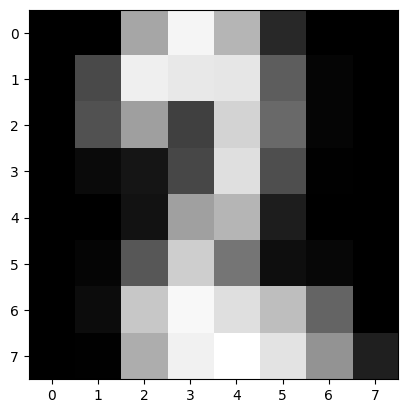

In [ ]:
###############################
## affichage des parametres: ##

## TODO: afficher les parametres appris sous un format lisible par l'humain

# Cette image représente la moyenne de tous les 2 dans notre data set d'entrainement
plt.imshow(p_kd[2].reshape(Dlin,Dlin), cm.gray)
plt.show()

###############################

# Bonus: on a un modèle génératif 

utilisez le modèle appris pour générer une image de la classe k=0, par exemple:

In [ ]:
## astuce: pour tirer au hasard 10 nombres d'apres une loi de Bernoulli 
## avec proba p, on peut faire:
p = 0.6
ma_va_de_bernoulli = np.random.random((10)) < p

ma_va_de_bernoulli

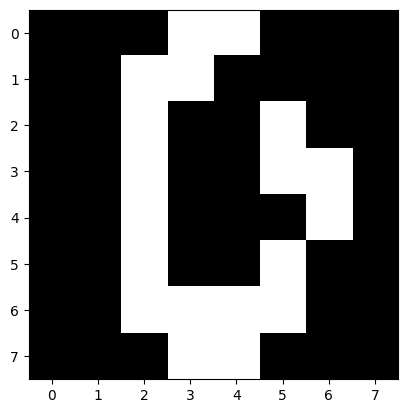

In [ ]:
## la feuille de brouillon:
k=0
D = X.shape[1]
imageGeneree = np.random.random(D) < p_kd[k]
# Ceci est un zéro généré en utilisant les paramètres P(X|Y) appris 
# On génére chaque pixel indépendament en lui donnant la probabilité p de valoir 1
# p étant la proportion de 1 pour ce pixel dans nos images d'entrainement de label k (ici k = 0)
plt.imshow(imageGeneree.reshape(Dlin,Dlin), cm.gray)

#### Maintenant, on peut faire par exemple, 5 iamgs-exemples générées pour chacune des K classes:

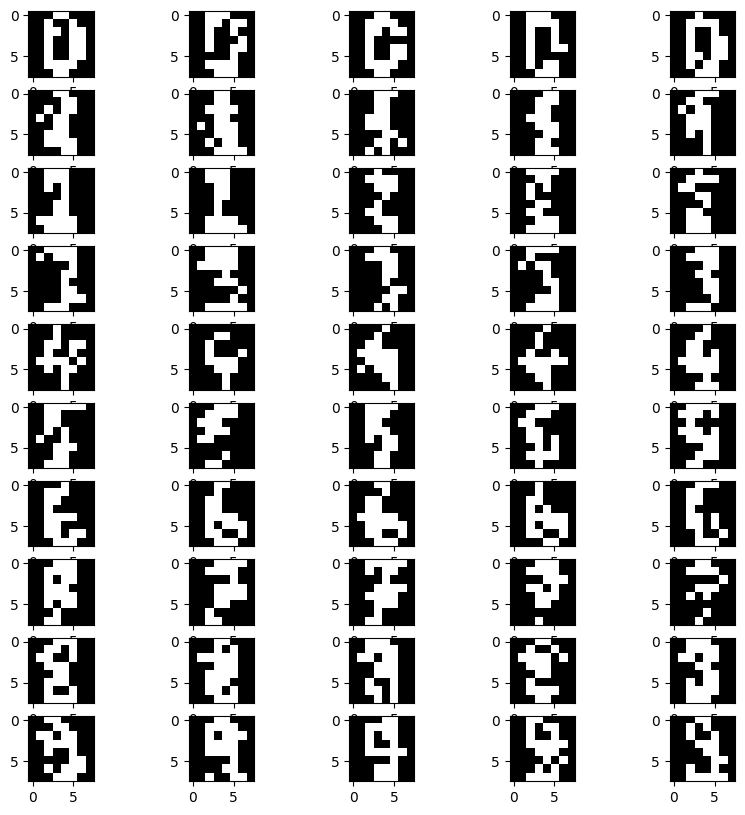

In [ ]:
NmbreImageParClasse = 5
fig, axs = plt.subplots(K, NmbreImageParClasse, figsize=(10, 10))

for k in range(K):
    for iteration in range(NmbreImageParClasse):
        
        imageGeneree =np.random.random(D) < p_kd[k]
        
        axs[k, iteration].imshow(imageGeneree.reshape(Dlin,Dlin), cm.gray)
#plt.tight_layout()
plt.show()

## Conclusion: ??

Est ce que vous voyez le problème de l'hypothèse "pixels indépendants" ?


In [ ]:
# Le résultat n'est pas du tout réaliste

## Bonus (difficile, ou plutot un peu long): 

Refaire l'entrainement avec pour modèle **une gaussienne avec une matrice de Covariance pleine et non diagonale.**

## conseil: 

**faire d'abord une PCA, car sinon le nombre de paramètres explose !!**